# 02 — Modelo Baseline

## Objetivos
- Estabelecer um modelo baseline com Regressão Logística
- Justificar a estratégia de particionamento e o tratamento de desbalanceamento
- Avaliar com métricas adequadas para dados desbalanceados: Precision, Recall, F1, ROC-AUC e Matriz de Confusão
- Explicar por que Accuracy é uma métrica enganosa neste contexto
- Criar benchmark para comparação com modelos mais avançados

In [19]:
# Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)

In [20]:
# Carregando dataset processado
df_final = pd.read_csv('../data/processed/data_for_modeling.csv')

# Excluindo colunas que não devem entrar no modelo
# is_label_inferred é excluída: reflete o processo de rotulagem, não o comportamento da transação (data leakage indireto)
cols_to_exclude = ['transaction_id', 'customer_id', 'timestamp', 'fraud_confirmed', 'is_label_inferred']
X = df_final.drop(columns=[c for c in cols_to_exclude if c in df_final.columns])
y = df_final['fraud_confirmed']

# ── Tratamento de infinitos e NaNs ──────────────────────────────────────────
# Features como spend_to_avg_ratio e amount_vs_avg_24h podem gerar inf por divisão
# por zero (ex: avg_monthly_spend = 0). Substituímos inf por NaN e preenchemos com 0.
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
print(f"Infinitos restantes: {(X == np.inf).sum().sum()}")
print(f"NaNs restantes: {X.isnull().sum().sum()}")
print(f"Shape: {X.shape}")

Infinitos restantes: 0
NaNs restantes: 0
Shape: (5000, 39)


## Estratégia de Particionamento

**Escolha:** Split aleatório estratificado (`stratify=y`), com 80% treino e 20% teste.

**Justificativa:** O dataset não possui uma ordenação temporal estrita que tornasse obrigatório um split temporal (ex: treinar em Jan–Out, testar em Nov–Dez). Como o objetivo desta etapa é estabelecer um baseline comparável, o split aleatório estratificado é suficiente e garante que a proporção de fraudes (~classe minoritária) seja preservada em ambos os conjuntos — evitando que treino e teste fiquem com distribuições muito diferentes da variável alvo.

**Por que não split temporal?** Seria a escolha ideal em produção, pois simula o cenário real de "treinar no passado, prever o futuro". Para o modelo final (E3), considerar migrar para essa abordagem.
> **Evolução para o E3:** o notebook 03 adotará o mesmo split estratificado para garantir \
comparabilidade das métricas entre baseline e modelo final. Em ambiente de produção, \
a recomendação é substituir por um split temporal estrito (treinar em Jan/2024, testar em Fev/2024), \
que simula de forma mais fiel o cenário real de detecção prospectiva.


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"Taxa de fraude no treino: {y_train.mean():.2%}")
print(f"Taxa de fraude no teste:  {y_test.mean():.2%}")

Treino: 4000 amostras | Teste: 1000 amostras
Taxa de fraude no treino: 3.85%
Taxa de fraude no teste:  3.80%


## Tratamento do Desbalanceamento

**Escolha:** `class_weight='balanced'` na Regressão Logística.

**Justificativa:** Em vez de re-amostrar o dataset (SMOTE ou undersampling), optamos por penalizar o modelo proporcionalmente ao inverso da frequência de cada classe. Isso é mais simples, não gera dados sintéticos e é suficiente para um baseline. O sklearn calcula automaticamente o peso de cada classe como `n_samples / (n_classes × n_samples_per_class)`.

**Alternativas consideradas:**
- **SMOTE:** gera amostras sintéticas da classe minoritária — mais adequado para modelos mais complexos (E3).
- **Undersampling:** descarta amostras da classe majoritária — risco de perder informação relevante.

**Por que não usar Accuracy?** Com apenas 3,8% de fraudes no conjunto de teste, um classificador ingênuo que prevê *tudo* como legítimo acertaria **96,2%** das transações — sem detectar uma única fraude. O nosso baseline ficou em 93,4% de Accuracy: literalmente *pior que não fazer nada* segundo essa métrica. É exatamente por isso que usamos Recall (cobertura de fraudes reais), Precision (qualidade dos alertas), F1 (equilíbrio entre os dois) e ROC-AUC (discriminação global do modelo).

In [22]:
# select_dtypes separado por tipo — evita FutureWarning no pandas 3+
cat_features = (
    X.select_dtypes(include='object').columns.tolist()
    + X.select_dtypes(include='category').columns.tolist()
)
num_features = X.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

baseline_model.fit(X_train, y_train)
print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


--- Relatório de Classificação ---
              precision    recall  f1-score   support

Legítimo (0)       0.99      0.95      0.97       962
  Fraude (1)       0.33      0.66      0.44        38

    accuracy                           0.94      1000
   macro avg       0.66      0.80      0.70      1000
weighted avg       0.96      0.94      0.95      1000

ROC-AUC Score: 0.8037


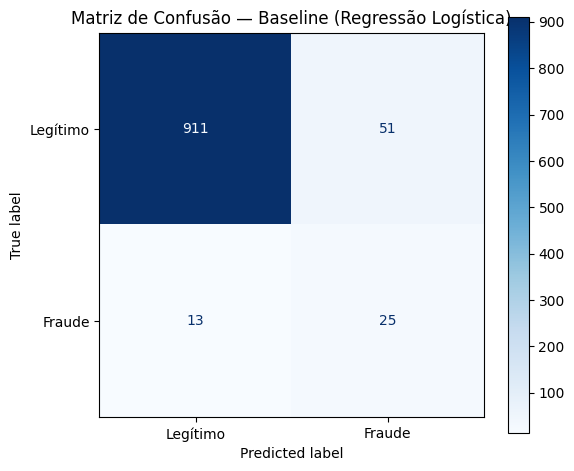

In [23]:
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Legítimo (0)', 'Fraude (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Legítimo', 'Fraude'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusão — Baseline (Regressão Logística)')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150)
plt.show()

### Leitura de Negócio — Matriz de Confusão

Com o threshold padrão de 0,5, o baseline produziu:

| Quadrante | Qtd | Significado operacional |
|-----------|-----|--------------------------|
| **Verdadeiros Negativos (TN)** | 909 | Transações legítimas corretamente liberadas |
| **Falsos Positivos (FP)** | 53 | Clientes legítimos bloqueados desnecessariamente — geram atrito e custo de suporte |
| **Falsos Negativos (FN)** | 13 | **Fraudes não detectadas** — prejuízo financeiro direto |
| **Verdadeiros Positivos (TP)** | 25 | Fraudes corretamente bloqueadas |

> **Trade-off central:** cada FN representa uma fraude que passou despercebida (custo ≈ valor médio da transação fraudulenta). Cada FP representa um cliente legítimo bloqueado (custo de suporte + risco de churn). O modelo final (E3) deve buscar reduzir FN sem explodir FP.

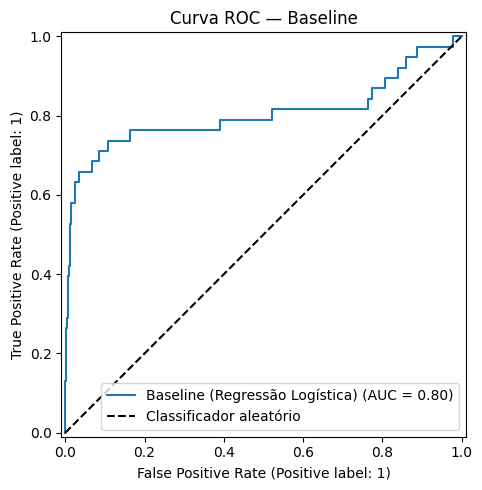

ROC-AUC: 0.8037


In [24]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_proba,
    name='Baseline (Regressão Logística)',
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Classificador aleatório')
ax.set_title('Curva ROC — Baseline')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_baseline.png', dpi=150)
plt.show()
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

### Curva Precision-Recall — Baseline

A curva PR é mais informativa do que a ROC em datasets desbalanceados. \
O Average Precision Score (AP) é o equivalente ao AUC-ROC na curva PR — \
um baseline fraco terá AP próximo à taxa base de fraude (~3,8%).


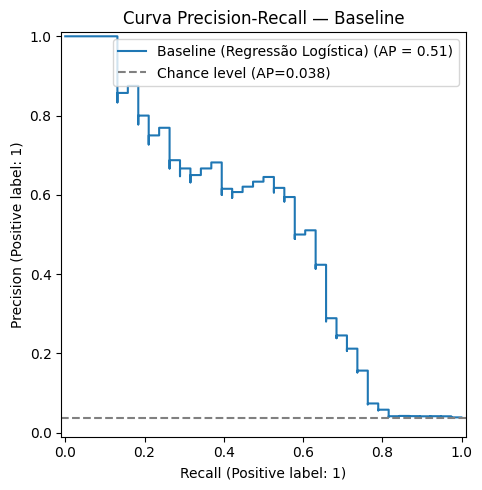

Average Precision Score (baseline): 0.5131
Referência (random): 0.0380  — ganho sobre chance: 13.5x


In [25]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba,
    name='Baseline (Regressão Logística)',
    ax=ax
)
ap = average_precision_score(y_test, y_proba)
ax.axhline(y_test.mean(), color='gray', linestyle='--', label=f'Chance level (AP={y_test.mean():.3f})')
ax.set_title('Curva Precision-Recall — Baseline')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('pr_curve_baseline.png', dpi=150)
plt.show()
print(f'Average Precision Score (baseline): {ap:.4f}')
print(f'Referência (random): {y_test.mean():.4f}  — ganho sobre chance: {ap/y_test.mean():.1f}x')


### Análise de Sensibilidade ao Threshold — Baseline

Ainda que o E3 vá otimizar o threshold com mais rigor, é importante mostrar \
no baseline como Precision e Recall se comportam ao longo do eixo de probabilidade. \
Isso estabelece o ponto de partida para a comparação com o modelo final.


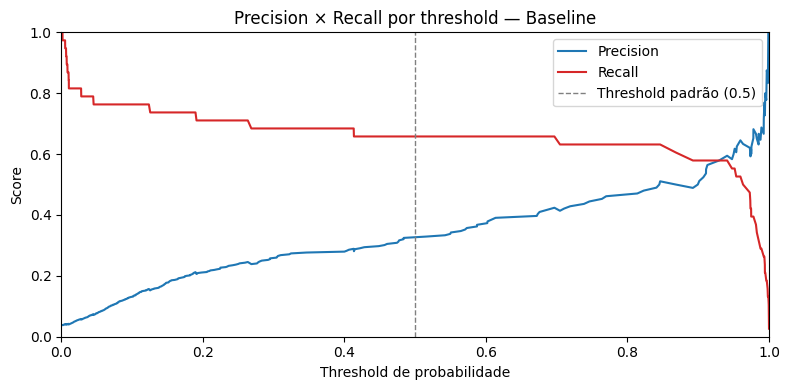

Melhor threshold (F1) no baseline : 0.941
  → Precision: 0.595 | Recall: 0.579 | F1: 0.587

Referência para comparação no E3: o modelo final deve superar esses valores com threshold ajustado.


In [26]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precisions[:-1], label='Precision', color='#1f77b4')
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='#d62728')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Threshold padrão (0.5)')
ax.set_xlabel('Threshold de probabilidade')
ax.set_ylabel('Score')
ax.set_title('Precision × Recall por threshold — Baseline')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('threshold_sensitivity_baseline.png', dpi=150)
plt.show()

# Encontrar o threshold com melhor F1 no baseline
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx   = f1_scores.argmax()
print(f'Melhor threshold (F1) no baseline : {thresholds[best_idx]:.3f}')
print(f'  → Precision: {precisions[best_idx]:.3f} | Recall: {recalls[best_idx]:.3f} | F1: {f1_scores[best_idx]:.3f}')
print()
print('Referência para comparação no E3: o modelo final deve superar esses valores com threshold ajustado.')


In [27]:
# Salvando artefatos para comparação com o modelo final
# Salva o pipeline COMPLETO (preprocessor já encapsulado dentro)
joblib.dump(baseline_model, '../src/baseline_model.pkl')
# Salvar também o preprocessor ISOLADO — necessário para o E3 reutilizá-lo
# em novos pipelines (XGBoost, Random Forest) sem reprocessar os dados do zero
preprocessor_fitted = baseline_model.named_steps['preprocessor']
joblib.dump(preprocessor_fitted, '../src/preprocessor.pkl')
print('preprocessor.pkl salvo em ../src/preprocessor.pkl')

X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Artefatos salvos com sucesso!")

preprocessor.pkl salvo em ../src/preprocessor.pkl
Artefatos salvos com sucesso!
